In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import unicodedata
import re
import os
from difflib import get_close_matches
# Importar Base


os.listdir('/kaggle/input/datasets/geraldinelaverde/giros-final')
ruta_archivo = '/kaggle/input/datasets/geraldinelaverde/giros-final/Giros_final.csv'

df_Giros_final = pd.read_csv(ruta_archivo, low_memory=False)

df_Giros_final.head()



,ANO,Fecha de pago,CÓDIGO DEPARTAMENTO,NOMBRE DEPARTAMENTO,CÓDIGO MUNICIPIO,NOMBRE MUNICIPIO,Identificacion- NIT,Nombre Razon Social,Descripcion,Fuente,Valor Girado,Concepto Pago,Ordenes de Pago,es_atipico
0,2015,2015-01-29,81.0,ARAUCA,81300.0,FORTUL,800136069,MUNICIPIO DE FORTUL,SISTEMA GENERAL DE PARTICIPACIONES SALUD PUBLI...,Nación,27047767,GIRO SGP SALUD PUBLICA VIG 2014,9207515,False
1,2015,2015-01-29,63.0,QUINDIO,63001.0,ARMENIA,890000464,MUNICIPIO DE ARMENIA,SISTEMA GENERAL DE PARTICIPACIONES SALUD PUBLI...,Nación,130243583,GIRO SGP SALUD PUBLICA VIG 2014,9207615,True
2,2015,2015-01-29,25.0,CUNDINAMARCA,25740.0,SIBATE,899999372,MUNICIPIO DE SIBATE,SISTEMA GENERAL DE PARTICIPACIONES SALUD PUBLI...,Nación,12600367,GIRO SGP SALUD PUBLICA VIG 2014,9207715,False
3,2015,2015-01-29,5.0,ANTIOQUIA,5088.0,BELLO,890980112,MUNICIPIO DE BELLO,SISTEMA GENERAL DE PARTICIPACIONES SALUD PUBLI...,Nación,214941350,GIRO SGP SALUD PUBLICA VIG 2014,9207815,True
4,2015,2015-01-29,5.0,ANTIOQUIA,5858.0,VEGACHI,890985285,MUNICIPIO DE VEGACHI,SISTEMA GENERAL DE PARTICIPACIONES SALUD PUBLI...,Nación,9040907,GIRO SGP SALUD PUBLICA VIG 2014,9207915,False


In [2]:
# ================================
# LIMPIEZA VALOR GIRADO
# ================================

df_Giros_final['Valor Girado'] = (
    df_Giros_final['Valor Girado']
    .astype(str)
    .str.replace(r'[^0-9,.-]', '', regex=True)  # quita $, espacios, letras
    .str.replace('.', '', regex=False)          # quita separador de miles
    .str.replace(',', '.', regex=False)        # cambia coma decimal a punto
)

df_Giros_final['Valor Girado'] = pd.to_numeric(
    df_Giros_final['Valor Girado'],
    errors='coerce'
)

print(df_Giros_final['Valor Girado'].dtype)
print("Nulos tras limpieza:", df_Giros_final['Valor Girado'].isna().sum())

int64
Nulos tras limpieza: 0


=== ANÁLISIS EXPLORATORIO DE DATOS - df_Giros_final ===

1. ESTADÍSTICAS DESCRIPTIVAS
📊 Variables numéricas:


,count,mean,min,25%,50%,75%,max,std
ANO,50065.0,2017.794947,2015.0,2015.0,2016.0,2020.0,2023.0,2.753085
Fecha de pago,50065,2018-04-20 09:14:08.425047296,2015-01-29 00:00:00,2015-12-04 00:00:00,2016-11-03 00:00:00,2020-05-07 00:00:00,2023-09-06 00:00:00,NaN
CÓDIGO DEPARTAMENTO,50033.0,37.54494,5.0,15.0,25.0,66.0,99.0,26.335858
CÓDIGO MUNICIPIO,47521.0,37223.639254,5001.0,15332.0,25805.0,63470.0,99773.0,25830.833261
Identificacion- NIT,50065.0,856483596.342135,322569122.0,800099429.0,890480126.0,891180155.0,900220147.0,44252268.422057
Valor Girado,50065.0,87224828.703605,19935.0,7543224.0,16194889.0,31524746.0,15939375420.0,363413188.017446



📝 Variables categóricas:


,count,unique,top,freq
NOMBRE DEPARTAMENTO,50033,34,ANTIOQUIA,7326
NOMBRE MUNICIPIO,47521,1013,SUCRE,197
Nombre Razon Social,50065,1128,MUNICIPIO DE GUADALUPE,148
Descripcion,50065,145,SISTEMA GENERAL DE PARTICIPACIONES SALUD - SAL...,3309
Fuente,50065,1,Nación,50065
Concepto Pago,50065,96,GIRO SGP SALUD PUBLICA VIG 2014,1133
Ordenes de Pago,50065,49284,SIN INFROMACION,391



2. DISTRIBUCIÓN DE VALOR GIRADO


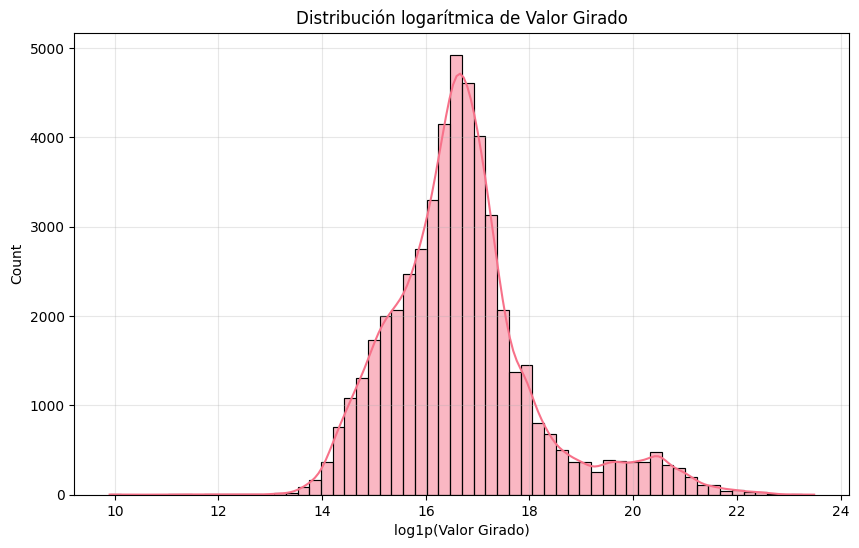


3. ANÁLISIS TEMPORAL POR AÑO


,Cantidad_Giros,Valor_Total,Valor_Promedio
ANO,,,
2015,13594,702173822859,51653216.0
2016,13582,757874411360,55799912.0
2017,392,387690224687,989005675.0
2018,408,391633228051,959885363.0
2019,9205,835910460442,90810479.0
2020,769,287815503719,374272437.0
2021,4278,335393216528,78399536.0
2022,4690,378313005377,80663754.0
2023,3147,290107176023,92185312.0


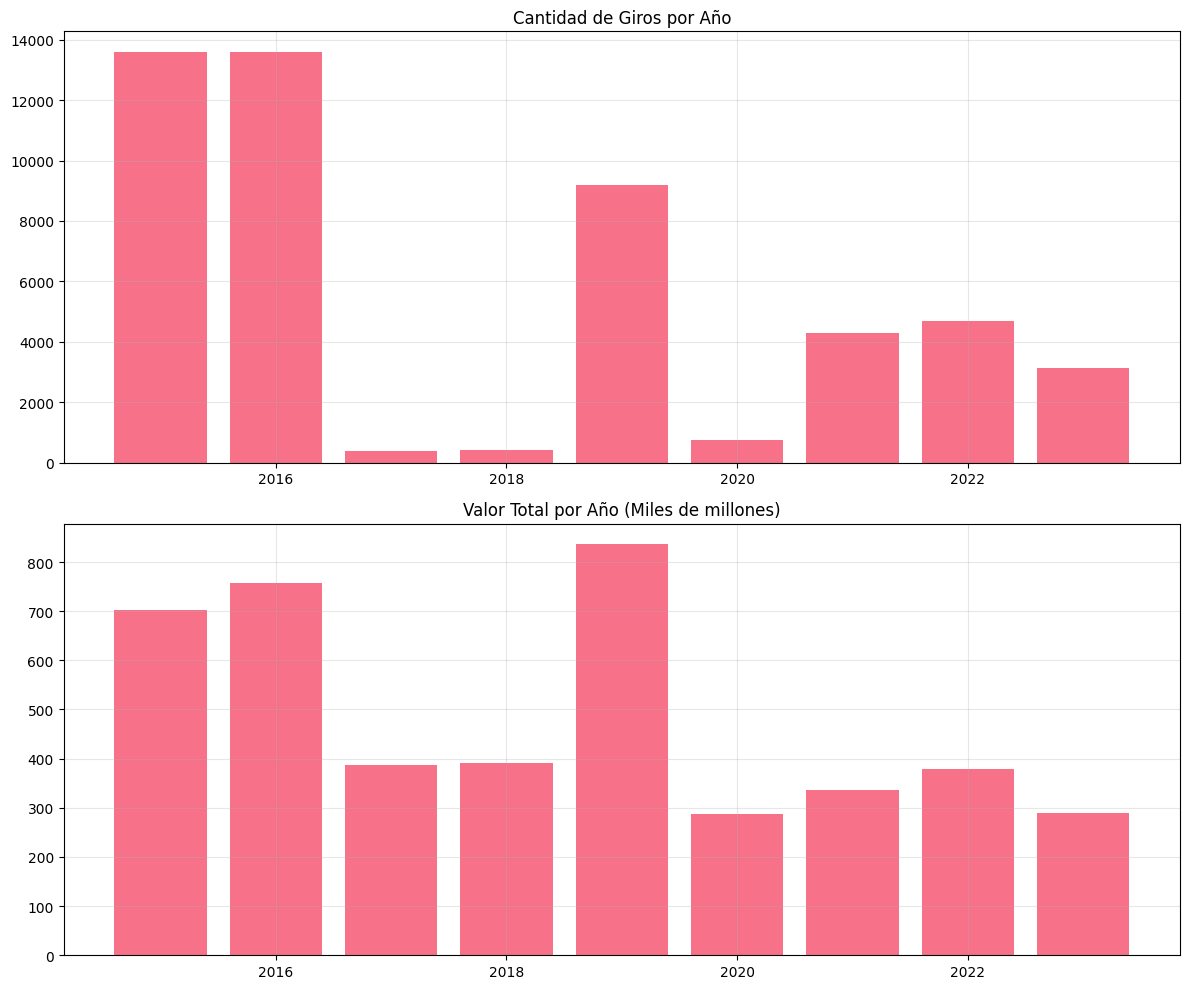


4. ANÁLISIS GEOGRÁFICO


,Cantidad_Giros,Valor_Total
NOMBRE DEPARTAMENTO,,
ANTIOQUIA,7326,477254355709
VALLE DEL CAUCA,1792,312400060486
BOGOTA D.C.,56,261109668918
BOLIVAR,2480,218663349922
CUNDINAMARCA,4197,202087200793
SANTANDER,4316,188652617694
NARINO,3524,181310373102
ATLANTICO,907,178519443050
CAUCA,1500,149920051133


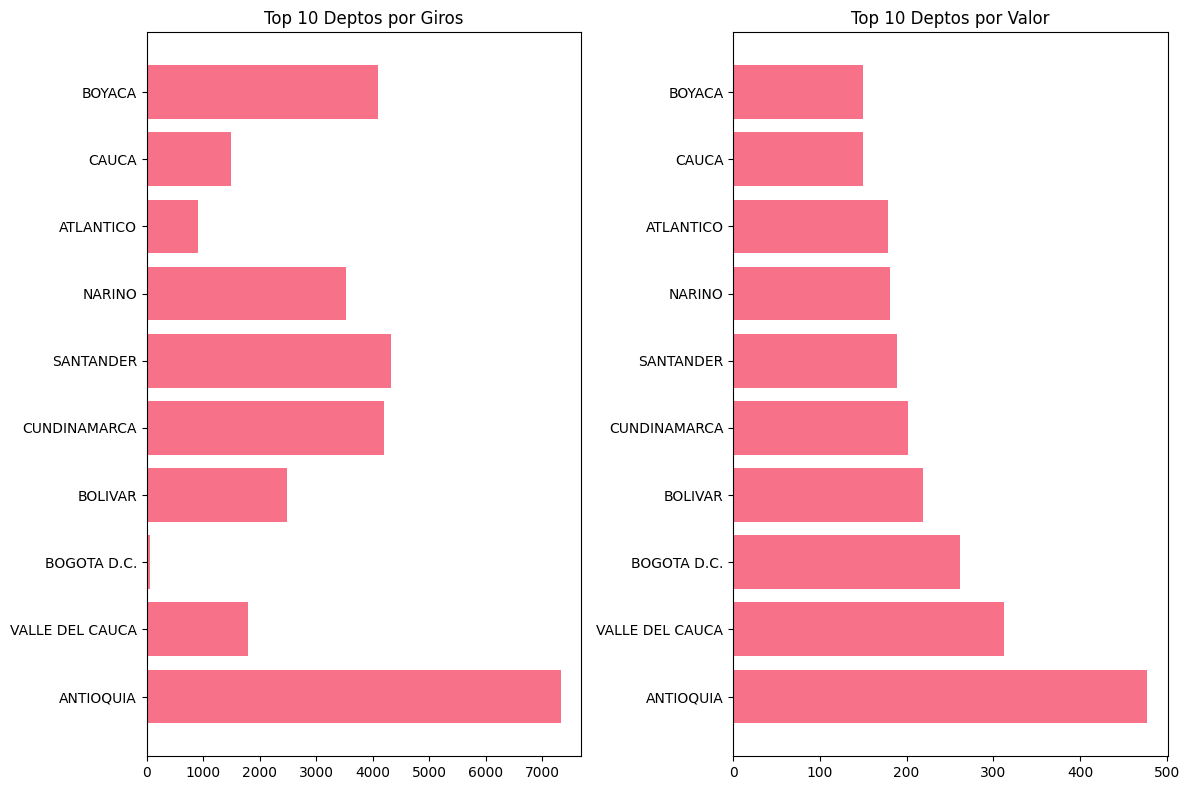


5. ANÁLISIS MUNICIPAL


,Cantidad_Giros,Valor_Total
NOMBRE MUNICIPIO,,
BOYACA,121,122759687582
BARRANQUILLA,56,58519012758
SANTIAGO DE CALI,32,53823250886
MEDELLIN,32,49183013432
SUCRE,197,45985306740
CARTAGENA DE INDIAS,56,45023511713
SAN ANDRES,121,42623364311
RISARALDA,121,38981333659
BUENAVENTURA,89,26413776110



6. VARIABLES CATEGÓRICAS CLAVE

>>> Fuente


Fuente
Nación    50065
Name: count, dtype: int64

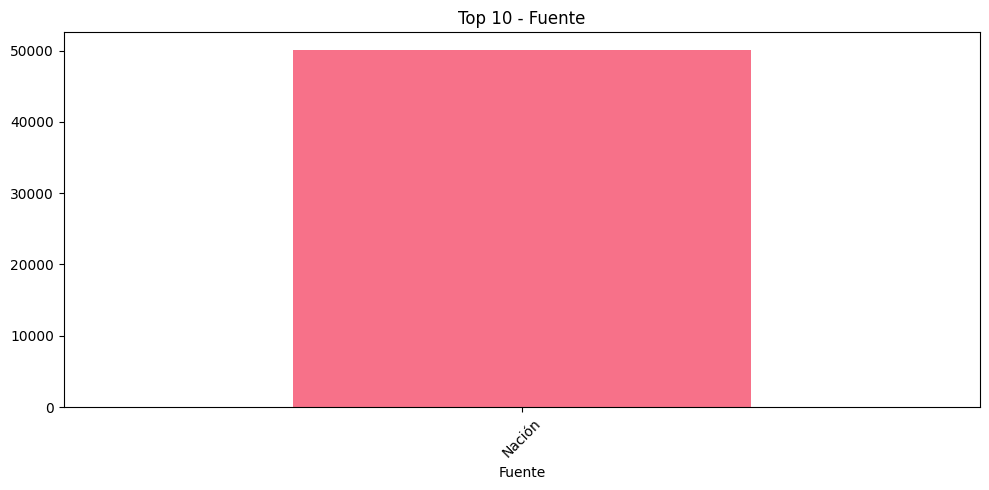


>>> Concepto Pago


Concepto Pago
GIRO SGP SALUD PUBLICA VIG 2014                      1133
GIRO SGP SALUD PUBLICA MES DE ENERO VIG 2015         1133
GIRO SGP SALUD PUBLICA MES DE FEBRERO VIG 2015       1133
GIRO SGP SALUD PUBLICA MES DE MARZO VIG 2015         1133
GIRO SGP SALUD PUBLICA MES DE ABRIL VIG 2015         1133
GIRO SGP SALUD PUBLICA MES DE MAYO VIG 2015          1133
GIRO SGP SALUD PUBLICA MES DE JUNIO VIG 2015         1133
GIRO SGP SALUD PUBLICA MES DE JULIO VIG 2015         1133
GIRO SGP SALUD PUBLICA MES DE AGOSTO VIG 2015        1133
GIRO SGP SALUD PUBLICA MES DE SEPTIEMBRE VIG 2015    1133
Name: count, dtype: int64

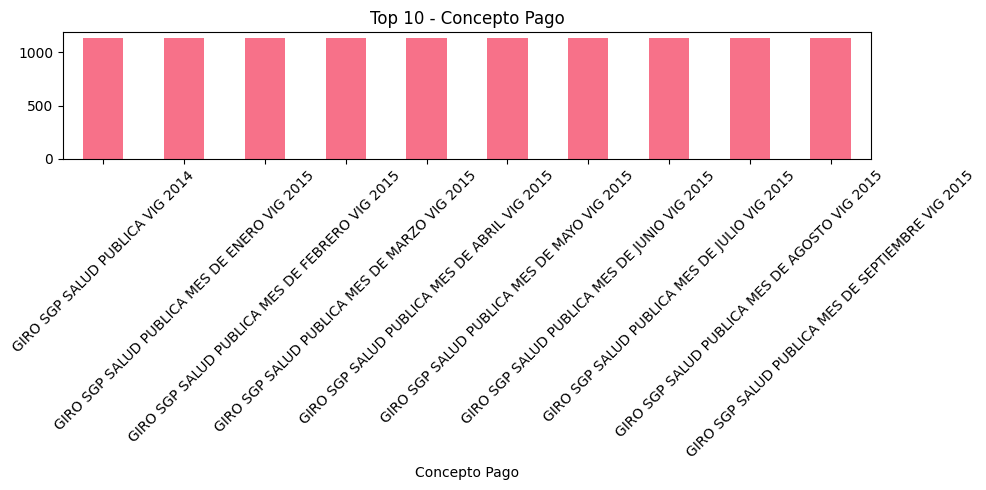


>>> Descripcion


Descripcion
SISTEMA GENERAL DE PARTICIPACIONES SALUD - SALUD PÚBLICA Y SUBSIDIO A LA OFERTA DEPARTAMENTO DE ANTIOQUIA    3309
SISTEMA GENERAL DE PARTICIPACIONES SALUD PUBLICA DEPARTAMENTO DE ANTIOQUIA                                   3024
SISTEMA GENERAL DE PARTICIPACIONES SALUD PUBLICA DEPARTAMENTO DE BOYACA                                      2976
SISTEMA GENERAL DE PARTICIPACIONES SALUD PUBLICA DEPARTAMENTO DE CUNDINAMARCA                                2806
SISTEMA GENERAL DE PARTICIPACIONES SALUD PUBLICA DEPARTAMENTO DE SANTANDER                                   2112
SISTEMA GENERAL DE PARTICIPACIONES SALUD PUBLICA DEPARTAMENTO DE NARIÑO                                      1560
SISTEMA GENERAL DE PARTICIPACIONES SALUD - SALUD PÚBLICA Y SUBSIDIO A LA OFERTA DEPARTAMENTO DE SANTANDER    1532
SISTEMA GENERAL DE PARTICIPACIONES SALUD - SALUD PÚBLICA Y SUBSIDIO A LA OFERTA DEPARTAMENTO DE NARIÑO       1371
SISTEMA GENERAL DE PARTICIPACIONES SALUD - SALUD PÚBLICA Y SUBSIDIO A LA OFE

/tmp/ipykernel_16/249087484.py:138: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


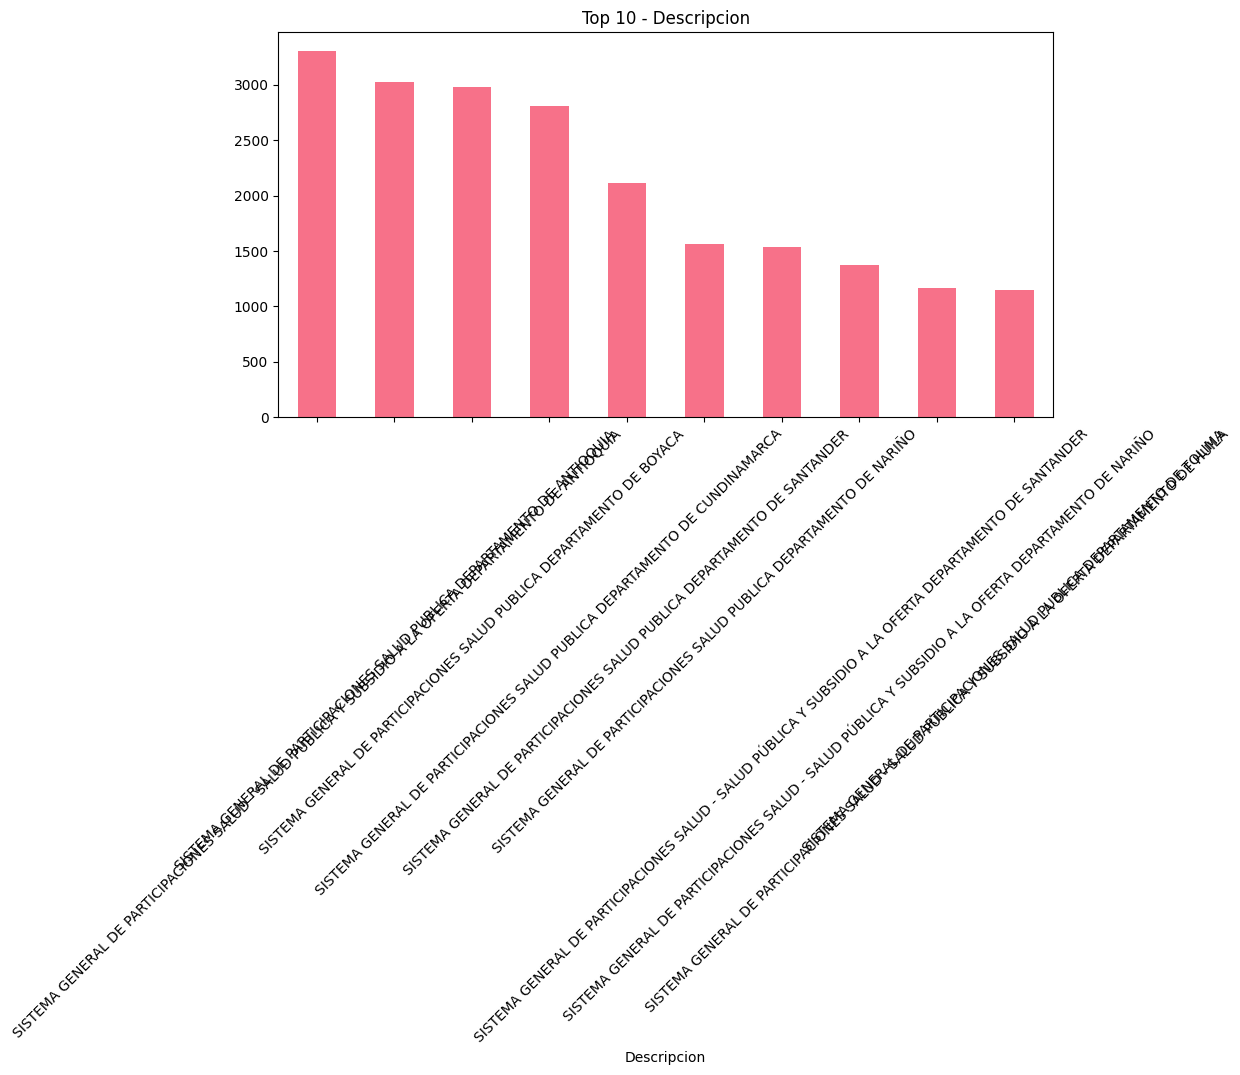


>>> Nombre Razon Social


Nombre Razon Social
MUNICIPIO DE GUADALUPE        148
MUNICIPIO DE EL PEÑON         132
MUNICIPIO DE EL CERRITO       131
MUNICIPIO DE LA PAZ           130
MUNICIPIO DE SANTA BARBARA    130
MUNICIPIO DE CONCEPCION       130
MUNICIPIO DE NARIÑO           130
MUNICIPIO DE SAN MARTIN       130
MUNICIPIO DE VILLANUEVA       129
MUNICIPIO DE ALBANIA          129
Name: count, dtype: int64

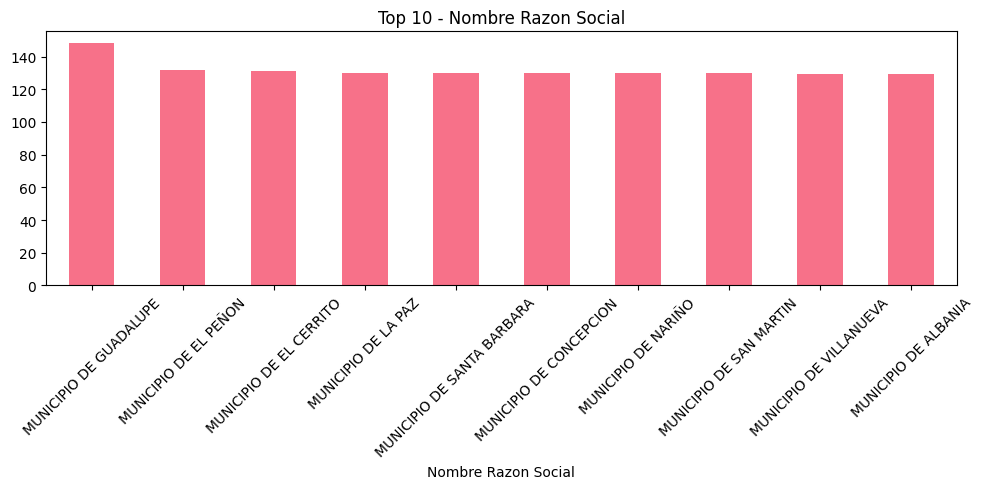


7. DETECCIÓN DE VALORES ATÍPICOS
Cantidad de giros atípicos: 6339


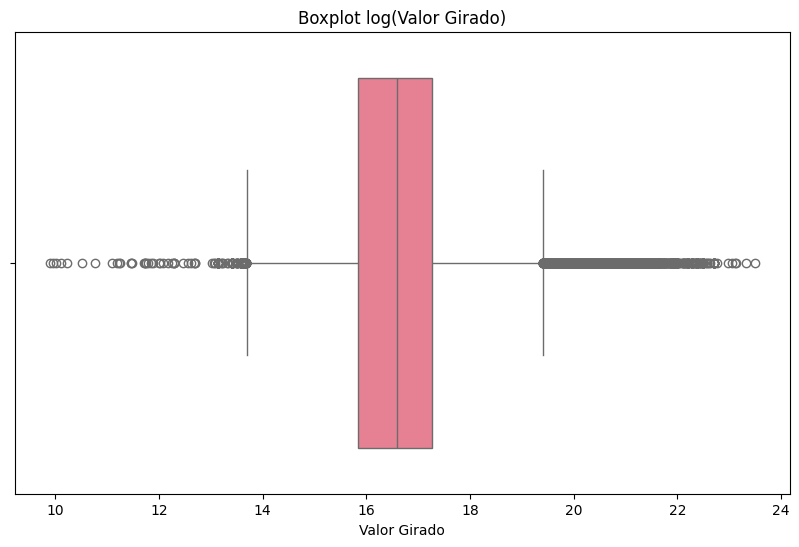


8. RESUMEN EJECUTIVO

Total giros: 50,065
Valor total girado: $4,366,911,049,046
Valor promedio: $87,224,829
Departamentos únicos: 33
Municipios únicos: 1095
Periodo: 2015 - 2023
Atípicos detectados: 6339

=== EDA COMPLETADO ===


In [3]:
# =============================================================================
# ANÁLISIS EXPLORATORIO DE DATOS (EDA) - df_Giros_final (ADAPTADO)
# =============================================================================


print("=== ANÁLISIS EXPLORATORIO DE DATOS - df_Giros_final ===\n")

plt.style.use('default')
sns.set_palette("husl")

# ----------------------------
# 0. PREPARACIÓN DE VARIABLES
# ----------------------------

df_Giros_final['Fecha de pago'] = pd.to_datetime(df_Giros_final['Fecha de pago'], errors='coerce')
df_Giros_final['ANO'] = df_Giros_final['Fecha de pago'].dt.year

# ----------------------------
# 1. ESTADÍSTICAS DESCRIPTIVAS
# ----------------------------

print("1. ESTADÍSTICAS DESCRIPTIVAS")
print("=" * 60)

print("📊 Variables numéricas:")
display(df_Giros_final.describe().T)

print("\n📝 Variables categóricas:")
display(df_Giros_final.describe(include="object").T)

# ----------------------------
# 2. DISTRIBUCIÓN VALOR GIRADO
# ----------------------------

print("\n2. DISTRIBUCIÓN DE VALOR GIRADO")
print("=" * 60)

plt.figure(figsize=(10,6))
sns.histplot(np.log1p(df_Giros_final['Valor Girado']), bins=60, kde=True)
plt.title("Distribución logarítmica de Valor Girado")
plt.xlabel("log1p(Valor Girado)")
plt.grid(True, alpha=0.3)
plt.show()

# ----------------------------
# 3. ANÁLISIS TEMPORAL
# ----------------------------

print("\n3. ANÁLISIS TEMPORAL POR AÑO")
print("=" * 60)

giros_ano = df_Giros_final.groupby('ANO').agg(
    Cantidad_Giros=('Valor Girado','count'),
    Valor_Total=('Valor Girado','sum'),
    Valor_Promedio=('Valor Girado','mean')
).round(0)

display(giros_ano)

fig, (ax1, ax2) = plt.subplots(2,1, figsize=(12,10))

ax1.bar(giros_ano.index, giros_ano['Cantidad_Giros'])
ax1.set_title('Cantidad de Giros por Año')
ax1.grid(True, alpha=0.3)

ax2.bar(giros_ano.index, giros_ano['Valor_Total']/1e9)
ax2.set_title('Valor Total por Año (Miles de millones)')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ----------------------------
# 4. ANÁLISIS GEOGRÁFICO
# ----------------------------

print("\n4. ANÁLISIS GEOGRÁFICO")
print("=" * 60)

deptos = df_Giros_final.groupby('NOMBRE DEPARTAMENTO').agg(
    Cantidad_Giros=('Valor Girado','count'),
    Valor_Total=('Valor Girado','sum')
).sort_values('Valor_Total', ascending=False)

display(deptos.head(10))

plt.figure(figsize=(12,8))
top = deptos.head(10)

plt.subplot(1,2,1)
plt.barh(top.index, top['Cantidad_Giros'])
plt.title('Top 10 Deptos por Giros')

plt.subplot(1,2,2)
plt.barh(top.index, top['Valor_Total']/1e9)
plt.title('Top 10 Deptos por Valor')

plt.tight_layout()
plt.show()

# ----------------------------
# 5. ANÁLISIS MUNICIPAL
# ----------------------------

print("\n5. ANÁLISIS MUNICIPAL")
print("=" * 60)

municipios = df_Giros_final.groupby('NOMBRE MUNICIPIO').agg(
    Cantidad_Giros=('Valor Girado','count'),
    Valor_Total=('Valor Girado','sum')
).sort_values('Valor_Total', ascending=False)

display(municipios.head(10))

# ----------------------------
# 6. VARIABLES CATEGÓRICAS CLAVE
# ----------------------------

print("\n6. VARIABLES CATEGÓRICAS CLAVE")
print("=" * 60)

cat_cols = [
    'Fuente',
    'Concepto Pago',
    'Descripcion',
    'Nombre Razon Social'
]

for col in cat_cols:
    print(f"\n>>> {col}")
    top = df_Giros_final[col].value_counts().head(10)
    display(top)

    plt.figure(figsize=(10,5))
    top.plot(kind='bar')
    plt.title(f'Top 10 - {col}')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# ----------------------------
# 7. DETECCIÓN DE ATÍPICOS (IQR)
# ----------------------------

print("\n7. DETECCIÓN DE VALORES ATÍPICOS")
print("=" * 60)

Q1 = df_Giros_final['Valor Girado'].quantile(0.25)
Q3 = df_Giros_final['Valor Girado'].quantile(0.75)
IQR = Q3 - Q1

limite_sup = Q3 + 1.5 * IQR

df_Giros_final['es_atipico'] = df_Giros_final['Valor Girado'] > limite_sup

print("Cantidad de giros atípicos:", df_Giros_final['es_atipico'].sum())

plt.figure(figsize=(10,6))
sns.boxplot(x=np.log1p(df_Giros_final['Valor Girado']))
plt.title("Boxplot log(Valor Girado)")
plt.show()

# ----------------------------
# 8. RESUMEN EJECUTIVO
# ----------------------------

print("\n8. RESUMEN EJECUTIVO")
print("=" * 60)

print(f"""
Total giros: {len(df_Giros_final):,}
Valor total girado: ${df_Giros_final['Valor Girado'].sum():,.0f}
Valor promedio: ${df_Giros_final['Valor Girado'].mean():,.0f}
Departamentos únicos: {df_Giros_final['CÓDIGO DEPARTAMENTO'].nunique()}
Municipios únicos: {df_Giros_final['CÓDIGO MUNICIPIO'].nunique()}
Periodo: {df_Giros_final['ANO'].min()} - {df_Giros_final['ANO'].max()}
Atípicos detectados: {df_Giros_final['es_atipico'].sum()}
""")

print("=== EDA COMPLETADO ===")

In [4]:

#Crear Mes

# Asegurar tipo fecha
df_Giros_final['Fecha de pago'] = pd.to_datetime(
    df_Giros_final['Fecha de pago'],
    errors='coerce',
    dayfirst=True
)

# Crear ANO y MES si no existen
df_Giros_final['ANO'] = df_Giros_final['Fecha de pago'].dt.year
df_Giros_final['MES'] = df_Giros_final['Fecha de pago'].dt.month

# Reordenar columnas: ANO, MES, resto
cols = ['ANO', 'MES'] + [c for c in df_Giros_final.columns if c not in ['ANO', 'MES']]
df_Giros_final = df_Giros_final[cols]

df_Giros_final.head()

,ANO,MES,Fecha de pago,CÓDIGO DEPARTAMENTO,NOMBRE DEPARTAMENTO,CÓDIGO MUNICIPIO,NOMBRE MUNICIPIO,Identificacion- NIT,Nombre Razon Social,Descripcion,Fuente,Valor Girado,Concepto Pago,Ordenes de Pago,es_atipico
0,2015,1,2015-01-29,81.0,ARAUCA,81300.0,FORTUL,800136069,MUNICIPIO DE FORTUL,SISTEMA GENERAL DE PARTICIPACIONES SALUD PUBLI...,Nación,27047767,GIRO SGP SALUD PUBLICA VIG 2014,9207515,False
1,2015,1,2015-01-29,63.0,QUINDIO,63001.0,ARMENIA,890000464,MUNICIPIO DE ARMENIA,SISTEMA GENERAL DE PARTICIPACIONES SALUD PUBLI...,Nación,130243583,GIRO SGP SALUD PUBLICA VIG 2014,9207615,True
2,2015,1,2015-01-29,25.0,CUNDINAMARCA,25740.0,SIBATE,899999372,MUNICIPIO DE SIBATE,SISTEMA GENERAL DE PARTICIPACIONES SALUD PUBLI...,Nación,12600367,GIRO SGP SALUD PUBLICA VIG 2014,9207715,False
3,2015,1,2015-01-29,5.0,ANTIOQUIA,5088.0,BELLO,890980112,MUNICIPIO DE BELLO,SISTEMA GENERAL DE PARTICIPACIONES SALUD PUBLI...,Nación,214941350,GIRO SGP SALUD PUBLICA VIG 2014,9207815,True
4,2015,1,2015-01-29,5.0,ANTIOQUIA,5858.0,VEGACHI,890985285,MUNICIPIO DE VEGACHI,SISTEMA GENERAL DE PARTICIPACIONES SALUD PUBLI...,Nación,9040907,GIRO SGP SALUD PUBLICA VIG 2014,9207915,False


In [5]:
os.makedirs('/kaggle/working/Giros_Procesados', exist_ok=True)

df_Giros_final.to_parquet('/kaggle/working/Giros_Procesados/Giros_final.parquet', index=False)
df_Giros_final.to_csv('/kaggle/working/Giros_Procesados/Giros_final.csv', index=False)
df_Giros_final.to_excel('/kaggle/working/Giros_Procesados/Giros_final.xlsx', index=False)

print("Listo")

Listo
